In [1]:
!pip install --user matplotlib
!pip install --user pandas
!pip install --user scipy
!pip install --user tqdm

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v4, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023

In [1]:
import matplotlib
%matplotlib inline

import _pickle as pickle
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy

from tqdm.notebook import tqdm

In [2]:
data_dir = "/home/chanb/scratch/hint_rl_results/logs/chanb/openmath-dapo/"
match_prefixes = [
    "local_eval-hint_rl_0-epoch",
    "local_eval-hint_rl_163-epoch",
]
all_evals = []
for match_prefix in match_prefixes:
    all_evals.extend(sorted([
        filename for filename in os.listdir(data_dir)
        if (
            os.path.isdir(os.path.join(data_dir, filename))
            and filename.startswith(match_prefix)
            and len(os.listdir(os.path.join(data_dir, filename, "rollout/0"))) == 1853
        )
    ], key=lambda x: int(x.split("epoch")[1])))

In [3]:
all_evals

['local_eval-hint_rl_0-epoch1epochstep13globalstep27',
 'local_eval-hint_rl_0-epoch2epochstep13globalstep41',
 'local_eval-hint_rl_0-epoch3epochstep13globalstep55',
 'local_eval-hint_rl_0-epoch4epochstep13globalstep69',
 'local_eval-hint_rl_0-epoch5epochstep13globalstep83',
 'local_eval-hint_rl_0-epoch6epochstep13globalstep97',
 'local_eval-hint_rl_0-epoch7epochstep13globalstep111',
 'local_eval-hint_rl_0-epoch8epochstep13globalstep125',
 'local_eval-hint_rl_0-epoch9epochstep13globalstep139',
 'local_eval-hint_rl_0-epoch10epochstep13globalstep153',
 'local_eval-hint_rl_0-epoch11epochstep9globalstep163',
 'local_eval-hint_rl_163-epoch0epochstep13globalstep13',
 'local_eval-hint_rl_163-epoch1epochstep13globalstep27',
 'local_eval-hint_rl_163-epoch2epochstep13globalstep41',
 'local_eval-hint_rl_163-epoch3epochstep13globalstep55',
 'local_eval-hint_rl_163-epoch4epochstep13globalstep69',
 'local_eval-hint_rl_163-epoch5epochstep13globalstep83',
 'local_eval-hint_rl_163-epoch6epochstep13globa

In [4]:
all_results = dict()

In [5]:
n_samples = 8
k_sampless = [1, 2, 4, 8]

In [16]:
# def pass_k(n_success, n_samples, k_samples):
#     pass_k = (
#         1 - scipy.special.comb(
#             n_samples - n_success,
#             k_samples,
#             exact=False,
#         ) / scipy.special.comb(n_samples, k_samples, exact=False)
#     )
#     return pass_k

def pass_k(n_success, n_samples, k_samples):
    pass_k = n_success / n_samples
    return pass_k

In [18]:
agg_filename = "agg_eval-per_model-success_rate.pkl"
if os.path.isfile(agg_filename):
    all_results = pickle.load(open(agg_filename, "rb"))
else:
    for eval_name in tqdm(all_evals):
        curr_dir = os.path.join(data_dir, eval_name)
        pretrained_steps = int(eval_name.split("hint_rl_")[1].split("-")[0])
        total_train_steps = pretrained_steps + int(eval_name.split("globalstep")[1])
        key = total_train_steps

        curr_pass_k_results = []
        for sample_filename in os.listdir(os.path.join(curr_dir, "rollout/0")):
            sample_file = os.path.join(curr_dir, "rollout/0", sample_filename)
            sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
            curr_pass_k_results.append([
                pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
                for k_samples in k_sampless
            ])

        curr_pass_k_results = np.mean(curr_pass_k_results, axis=0)

        all_results[key] = curr_pass_k_results
    pickle.dump(all_results, open(agg_filename, "wb"))

  0%|          | 0/44 [00:00<?, ?it/s]

In [19]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint"

baseline_pass_k_results = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results = np.mean(baseline_pass_k_results, axis=0)

In [20]:
baseline_pass_k_results

array([0.07332704, 0.07332704, 0.07332704, 0.07332704])

In [21]:
baseline_dir = "/home/chanb/scratch/hint_rl_results/eval_results/per_model/local_eval-questa_no_hint-paper_model"

baseline_pass_k_results_2 = []
for sample_filename in os.listdir(os.path.join(baseline_dir, "rollout/0")):
    sample_file = os.path.join(baseline_dir, "rollout/0", sample_filename)
    sample_result = pd.read_json(path_or_buf=sample_file, lines=True)
    baseline_pass_k_results_2.append([
        pass_k(np.sum(sample_result["reward"].to_numpy()), n_samples, k_samples)
        for k_samples in k_sampless
    ])

baseline_pass_k_results_2 = np.mean(baseline_pass_k_results_2, axis=0)

In [22]:
baseline_pass_k_results_2

array([0.33553697, 0.33553697, 0.33553697, 0.33553697])

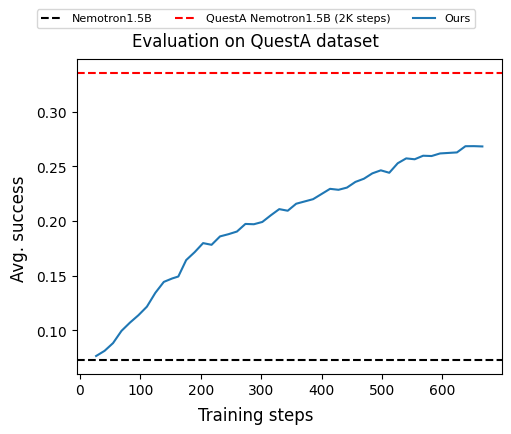

In [23]:
n_rows = 1
n_cols = 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 4.0 * n_rows), layout="constrained")

log_k = 2

x_range = sorted(all_results.keys())
y_vals = [
    all_results[key][log_k] for key in x_range
]

ax = axes
ax.axhline(
    baseline_pass_k_results[log_k],
    c="black",
    linestyle="--",
    label="Nemotron1.5B",
)
ax.axhline(
    baseline_pass_k_results_2[log_k],
    c="red",
    linestyle="--",
    label="QuestA Nemotron1.5B (2K steps)",
)
ax.plot(
    x_range,
    y_vals,
    label="Ours",
)
# ax.set_xticks(x_range)
# ax.set_ylim(-0.1, 1.1)

fig.suptitle("Evaluation on QuestA dataset")
# fig.supylabel("Pass@4")
fig.supylabel("Avg. success")
fig.supxlabel("Training steps")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=7,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

plt.show()

In [12]:
all_results

{27: array([0.07663249, 0.12818981, 0.19979955, 0.285483  ]),
 41: array([0.08135456, 0.13682445, 0.21383085, 0.30652995]),
 55: array([0.08843767, 0.14829234, 0.22979724, 0.32649757]),
 69: array([0.09963573, 0.16799013, 0.26193046, 0.37236913]),
 83: array([0.10719104, 0.17828232, 0.27256958, 0.37830545]),
 97: array([0.11393686, 0.18832395, 0.28509753, 0.39341608]),
 111: array([0.12176201, 0.20162285, 0.30732403, 0.42525634]),
 125: array([0.13444414, 0.22058824, 0.33019813, 0.44684296]),
 139: array([0.14442795, 0.23463881, 0.34779894, 0.47004857]),
 153: array([0.14759849, 0.23884049, 0.35281782, 0.47652455]),
 163: array([0.1493524 , 0.24304217, 0.35827615, 0.47652455]),
 176: array([0.16439557, 0.2602151 , 0.37244623, 0.48354021]),
 190: array([0.1716136 , 0.27120114, 0.38795004, 0.50350783]),
 204: array([0.17991096, 0.28095367, 0.39814201, 0.51592013]),
 218: array([0.17835942, 0.27858299, 0.39514301, 0.50782515]),
 232: array([0.18604965, 0.28590702, 0.40021587, 0.51430113])